In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

2774


/var/folders/xn/9gqx3sxx3s32k1ttvhjc4fch0000gn/T/ipykernel_6484/1359281906.py:5: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  secchi_dates["Year"] = pd.to_datetime(secchi_dates["Date"]).dt.year


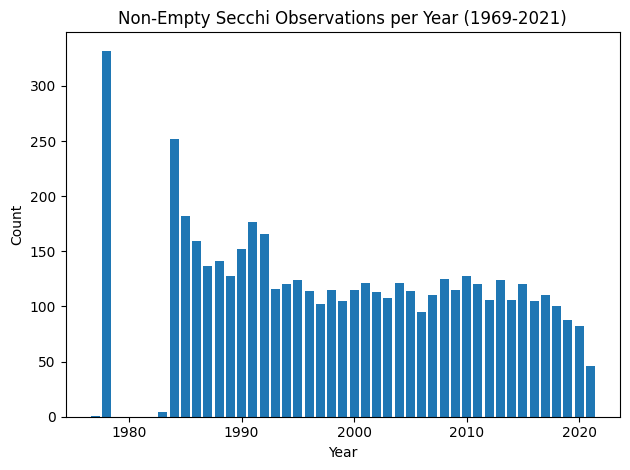

In [23]:
sechi_non_empty = df.loc[df["Secchi"].notna(), "Date"]
print(len(sechi_non_empty))

secchi_dates = pd.read_csv("../../data/secchi_non_empty_dates.csv")
secchi_dates["Year"] = pd.to_datetime(secchi_dates["Date"]).dt.year
year_counts = secchi_dates[secchi_dates["Year"].between(1969, 2021)].groupby("Year").size()

plt.figure()
plt.bar(year_counts.index, year_counts.values)
plt.xlabel("Year")
plt.ylabel("Count")
plt.title("Non-Empty Secchi Observations per Year (1969-2021)")
plt.tight_layout()
plt.show()

In [ ]:
# data is stored outside of repository folder in order to keep it out of the repo
df = pd.read_parquet('../../data/merged_dataset_organized.parquet')
print(df.head())
print(df.columns)

   ORD_OCC    CAST_ID         DATE_TIME_UTC         DATE_TIME_PST  LAT_DEC  \
0      1.0  9308_001d  1993-08-11T12:05:46Z  1993-08-11T04:05:46Z      NaN   
1      1.0  9308_001d  1993-08-11T12:06:04Z  1993-08-11T04:06:04Z    -99.0   
2      1.0  9308_001d  1993-08-11T12:06:10Z  1993-08-11T04:06:10Z    -99.0   
3      1.0  9308_001d  1993-08-11T12:06:11Z  1993-08-11T04:06:11Z    -99.0   
4      1.0  9308_001d  1993-08-11T12:06:14Z  1993-08-11T04:06:14Z    -99.0   

   LON_DEC       STA_ID  DEPTH  PRESSURE  TEMP1  ...  Secchi  IntChl  IntC14  \
0      NaN  093.3 026.7    2.0      2.01  20.98  ...     NaN     NaN     NaN   
1    -99.0  093.3 026.7    3.0      3.02  20.89  ...     NaN     NaN     NaN   
2    -99.0  093.3 026.7    4.0      4.02  20.81  ...     NaN     NaN     NaN   
3    -99.0  093.3 026.7    5.0      5.03  20.69  ...     NaN     NaN     NaN   
4    -99.0  093.3 026.7    6.0      6.04  20.68  ...     NaN     NaN     NaN   

   TimeZone  Wave_Dir  Wave_Ht  Wave_Prd  Wind_Dir

### Our effective data range is from 8/11/93 to 5/6/2021
Downcast CTD calCOFI data first date: 1993-08-11T04:05:46Z

Secchi depth last date: 5/6/2021

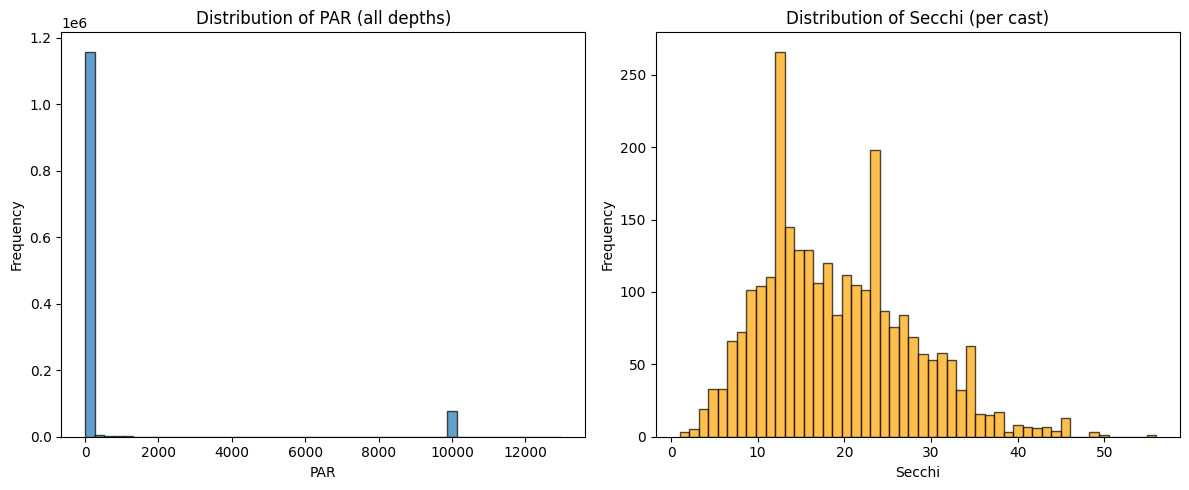

In [14]:
# Distribution comparison of PAR and Secchi
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# PAR distribution (all values across depths)
axes[0].hist(df['PAR'].dropna(), bins=50, edgecolor='black', alpha=0.7)
axes[0].set_xlabel('PAR')
axes[0].set_ylabel('Frequency')
axes[0].set_title('Distribution of PAR (all depths)')

# Secchi distribution (one per CAST_COUNT)
secchi_per_cast = df.groupby('CAST_COUNT')['Secchi'].first()
axes[1].hist(secchi_per_cast.dropna(), bins=50, edgecolor='black', alpha=0.7, color='orange')
axes[1].set_xlabel('Secchi')
axes[1].set_ylabel('Frequency')
axes[1].set_title('Distribution of Secchi (per cast)')

plt.tight_layout()
plt.show()

In [15]:
par_agg = df.groupby('CAST_COUNT')['PAR'].agg(['mean', 'max', 'min']).rename(
    columns={'mean': 'PAR_mean', 'max': 'PAR_max', 'min': 'PAR_min'}
)
secchi_agg = df.groupby('CAST_COUNT')['Secchi'].first()

# Combine for correlation
corr_df = par_agg.join(secchi_agg).dropna()

print(f"\nCorrelation between Secchi and PAR metrics (n={len(corr_df)} casts):")
print(corr_df.corr()['Secchi'])


Correlation between Secchi and PAR metrics (n=2774 casts):
PAR_mean   -0.038932
PAR_max     0.054694
PAR_min    -0.025560
Secchi      1.000000
Name: Secchi, dtype: float64


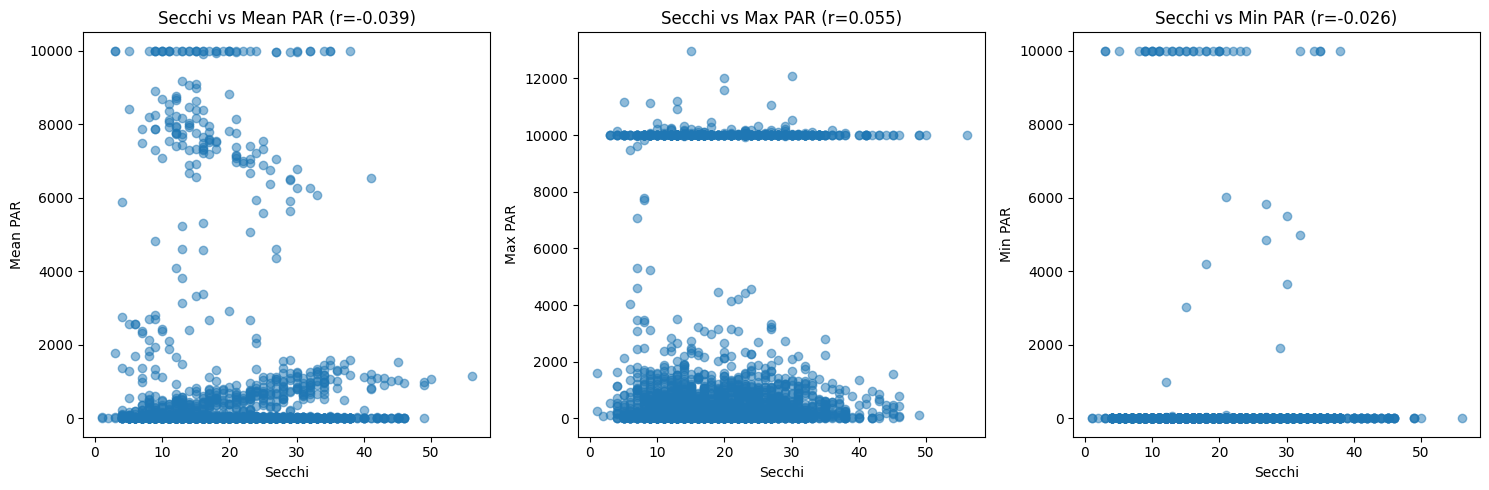

In [16]:
# Scatter plot: Secchi vs mean PAR
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

axes[0].scatter(corr_df['Secchi'], corr_df['PAR_mean'], alpha=0.5)
axes[0].set_xlabel('Secchi')
axes[0].set_ylabel('Mean PAR')
axes[0].set_title(f"Secchi vs Mean PAR (r={corr_df['Secchi'].corr(corr_df['PAR_mean']):.3f})")

axes[1].scatter(corr_df['Secchi'], corr_df['PAR_max'], alpha=0.5)
axes[1].set_xlabel('Secchi')
axes[1].set_ylabel('Max PAR')
axes[1].set_title(f"Secchi vs Max PAR (r={corr_df['Secchi'].corr(corr_df['PAR_max']):.3f})")

axes[2].scatter(corr_df['Secchi'], corr_df['PAR_min'], alpha=0.5)
axes[2].set_xlabel('Secchi')
axes[2].set_ylabel('Min PAR')
axes[2].set_title(f"Secchi vs Min PAR (r={corr_df['Secchi'].corr(corr_df['PAR_min']):.3f})")

plt.tight_layout()
plt.show()

No meaningful relationship was found between PAR and secchi initially, so let's look into the euphotic depth vs Secchi depth.

In [17]:
# Check distribution of minimum depths per cast
min_depths = df.groupby('CAST_COUNT')['DEPTH'].min()
print(f"\nMinimum depth distribution across casts:")
print(min_depths.value_counts().sort_index().head(10))



Minimum depth distribution across casts:
DEPTH
1.0      741
2.0     1547
3.0      422
4.0       47
5.0        5
6.0        1
7.0        1
8.0        1
11.0       1
12.0       4
Name: count, dtype: int64


In [18]:
# Calculate euphotic depth (depth where PAR = 1% of surface PAR)
def calculate_euphotic_depth(group):
    """Calculate euphotic depth for a single cast using linear interpolation."""
    # Sort by depth and drop rows with missing PAR
    group = group.sort_values('DEPTH').dropna(subset=['PAR'])
    if len(group) < 2:
        return np.nan

    # Surface PAR is at shallowest depth
    surface_par = group['PAR'].iloc[0]
    if surface_par <= 0:
        return np.nan

    # Calculate PAR as percentage of surface
    group = group.copy()
    group['PAR_pct'] = (group['PAR'] / surface_par) * 100

    # Find where PAR crosses 1% threshold
    above_1pct = group[group['PAR_pct'] >= 1]
    below_1pct = group[group['PAR_pct'] < 1]

    if len(below_1pct) == 0:
        # PAR never drops below 1% - euphotic depth is deeper than max depth
        return np.nan
    if len(above_1pct) == 0:
        # PAR is always below 1% - shouldn't happen if surface is reference
        return np.nan

    # Linear interpolation between last point >=1% and first point <1%
    depth_above = above_1pct['DEPTH'].iloc[-1]
    depth_below = below_1pct['DEPTH'].iloc[0]
    par_pct_above = above_1pct['PAR_pct'].iloc[-1]
    par_pct_below = below_1pct['PAR_pct'].iloc[-1]

    # Interpolate to find depth at exactly 1%
    euphotic_depth = depth_above + (depth_below - depth_above) * (par_pct_above - 1) / (par_pct_above - par_pct_below)

    return euphotic_depth

# Calculate euphotic depth for each cast
euphotic_depths = df.groupby('CAST_COUNT').apply(calculate_euphotic_depth)
euphotic_depths.name = 'euphotic_depth'

# Combine with Secchi for correlation
secchi_per_cast = df.groupby('CAST_COUNT')['Secchi'].first()
euphotic_df = pd.DataFrame({'euphotic_depth': euphotic_depths, 'Secchi': secchi_per_cast}).dropna()

print(f"\nEuphotic depth statistics (n={len(euphotic_df)} casts with valid data):")
print(euphotic_df['euphotic_depth'].describe())

print(f"\nCorrelation between Secchi and Euphotic Depth:")
corr = euphotic_df['Secchi'].corr(euphotic_df['euphotic_depth'])
print(f"r = {corr:.4f}")


Euphotic depth statistics (n=2336 casts with valid data):
count    2336.000000
mean       58.258111
std        44.436194
min         2.980000
25%        36.094377
50%        53.023422
75%        75.009813
max       937.002843
Name: euphotic_depth, dtype: float64

Correlation between Secchi and Euphotic Depth:
r = 0.4211


/var/folders/xn/9gqx3sxx3s32k1ttvhjc4fch0000gn/T/ipykernel_6484/2472427711.py:41: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  euphotic_depths = df.groupby('CAST_COUNT').apply(calculate_euphotic_depth)


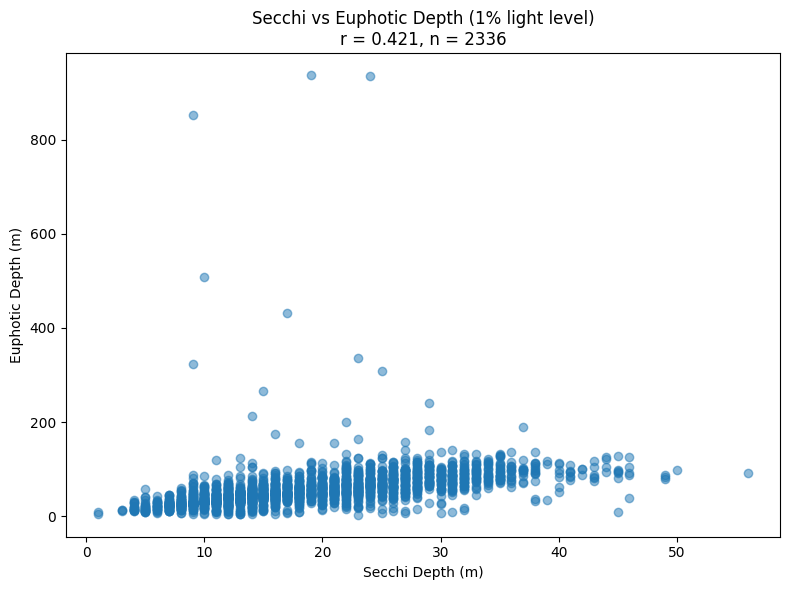

In [19]:
# Scatter plot: Secchi vs Euphotic Depth
plt.figure(figsize=(8, 6))
plt.scatter(euphotic_df['Secchi'], euphotic_df['euphotic_depth'], alpha=0.5)
plt.xlabel('Secchi Depth (m)')
plt.ylabel('Euphotic Depth (m)')
plt.title(f'Secchi vs Euphotic Depth (1% light level)\nr = {corr:.3f}, n = {len(euphotic_df)}')
plt.tight_layout()
plt.show()

Euphotic depth (2m baseline) statistics (n=1911 casts):
count    1911.000000
mean       58.093489
std        34.376079
min         3.980000
25%        37.031480
50%        53.023987
75%        75.620328
max       507.540000
Name: euphotic_depth, dtype: float64

Correlation between Secchi and Euphotic Depth (2m baseline):
r = 0.5451


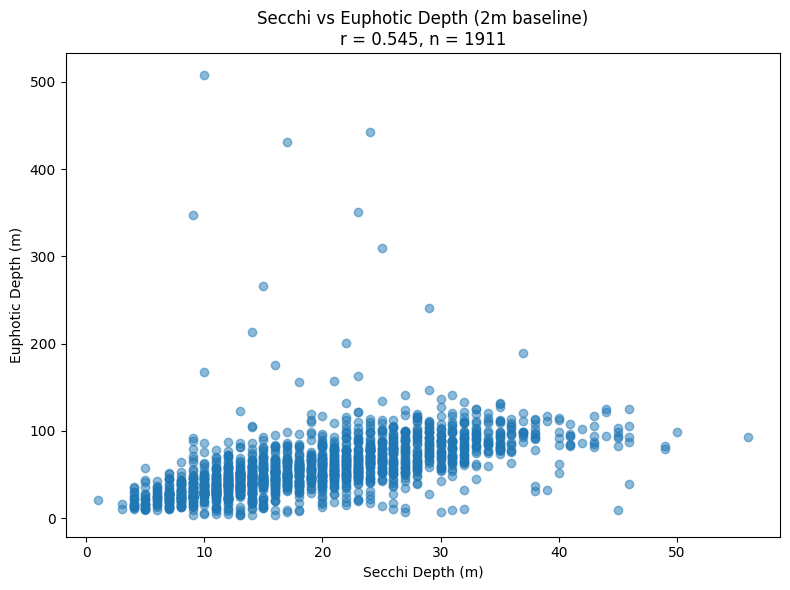

In [ ]:
# Recalculate euphotic depth using only casts with 2m as baseline depth - suggested by Rasmus
def calculate_euphotic_depth_2m(group):
    """Calculate euphotic depth using PAR at 2m depth as the surface reference."""
    # Sort by depth and drop rows with missing PAR
    group = group.sort_values('DEPTH').dropna(subset=['PAR'])
    
    # Check if we have a measurement at exactly 2m depth
    depth_2m = group[group['DEPTH'] == 2.0]
    if len(depth_2m) == 0 or len(group) < 2:
        return np.nan
    
    # Use PAR at 2m as the surface reference
    surface_par = depth_2m['PAR'].iloc[0]
    if surface_par <= 0:
        return np.nan
    
    # Only use depths >= 2m
    group = group[group['DEPTH'] >= 2.0].copy()
    group['PAR_pct'] = (group['PAR'] / surface_par) * 100
    
    # Find where PAR crosses 1% threshold
    above_1pct = group[group['PAR_pct'] >= 1]
    below_1pct = group[group['PAR_pct'] < 1]
    
    if len(below_1pct) == 0:
        return np.nan
    if len(above_1pct) == 0:
        return np.nan
    
    # Linear interpolation
    depth_above = above_1pct['DEPTH'].iloc[-1]
    depth_below = below_1pct['DEPTH'].iloc[0]
    par_pct_above = above_1pct['PAR_pct'].iloc[-1]
    par_pct_below = below_1pct['PAR_pct'].iloc[0]
    
    euphotic_depth = depth_above + (depth_below - depth_above) * (par_pct_above - 1) / (par_pct_above - par_pct_below)
    
    return euphotic_depth

# Calculate euphotic depth for casts with 2m baseline
euphotic_depths_2m = df.groupby('CAST_COUNT').apply(calculate_euphotic_depth_2m, include_groups=False)
euphotic_depths_2m.name = 'euphotic_depth_2m'

# Combine with Secchi for correlation
euphotic_df_2m = pd.DataFrame({'euphotic_depth': euphotic_depths_2m, 'Secchi': secchi_per_cast}).dropna()

print(f"Euphotic depth (2m baseline) statistics (n={len(euphotic_df_2m)} casts):")
print(euphotic_df_2m['euphotic_depth'].describe())

print(f"\nCorrelation between Secchi and Euphotic Depth (2m baseline):")
corr_2m = euphotic_df_2m['Secchi'].corr(euphotic_df_2m['euphotic_depth'])
print(f"r = {corr_2m:.4f}")

# Scatter plot
plt.figure(figsize=(8, 6))
plt.scatter(euphotic_df_2m['Secchi'], euphotic_df_2m['euphotic_depth'], alpha=0.5)
plt.xlabel('Secchi Depth (m)')
plt.ylabel('Euphotic Depth (m)')
plt.title(f'Secchi vs Euphotic Depth (2m baseline)\nr = {corr_2m:.3f}, n = {len(euphotic_df_2m)}')
plt.tight_layout()
plt.show()

Suggestions from Rasmus:

Keep cholorphyll a, transmisommeter, weather stuff
Look at line and station, split up correlations including all stations 60 or less (ignore line) and stations 61+ are stations away from shore

Look at chlorophyll a and transmisometer (captures any particles passing my light beam sensor - shows decrease in light) data next week
More material passing by transmisometer --> shallower secchi depth (more productivity)
Integrate transmisometer readings within euphotic zone calcualtiosn/correlaitnos


In [24]:
df2 = pd.read_csv("../../data/merged_dataset_organized_photic.csv")
print(df2.columns)

Index(['ORD_OCC', 'CAST_ID', 'DATE_TIME_UTC', 'DATE_TIME_PST', 'LAT_DEC',
       'LON_DEC', 'STA_ID', 'LINE', 'STA', 'DEPTH', 'PRESSURE',
       'ESTCHL_CRUISECORR', 'ESTCHL_STACORR', 'BAT', 'XMISS', 'SPAR', 'PAR',
       'CHL_A', 'PHAEO', 'CAST_COUNT', 'Cruise_ID', 'Cruz_Sta', 'Cast_ID',
       'Sta_ID', 'Distance', 'Date', 'Time', 'Lat_Dec', 'Lon_Dec', 'Ac_Line',
       'Bottom_D', 'Secchi', 'IntChl', 'IntC14', 'TimeZone', 'Visibility',
       'PHOTIC_ZONE'],
      dtype='object')


### `merged_dataset_organized_45photic` has the column `PHOTIC_ZONE` taking boolean values to show which depth is the photic zone

#### Since we calculated photic zone (depth at which 1% of light is left compared to surface) using the baseline PAR depth as 2 m (the most common depth PAR started at), we adjusted and calculated photic depth as the depth at which 4.5% of light was left compared to 2 m

In [2]:
# New dataset calcualting photic zone defining it as the depth at which 4.5% of light reaches (using 2m depth as baseline)

df3 = pd.read_csv("../../data/merged_dataset_organized_45photic.csv")
print(df3.columns)

Index(['ORD_OCC', 'CAST_ID', 'DATE_TIME_UTC', 'DATE_TIME_PST', 'LAT_DEC',
       'LON_DEC', 'STA_ID', 'LINE', 'STA', 'DEPTH', 'PRESSURE',
       'ESTCHL_CRUISECORR', 'ESTCHL_STACORR', 'BAT', 'XMISS', 'SPAR', 'PAR',
       'CHL_A', 'PHAEO', 'CAST_COUNT', 'Cruise_ID', 'Cruz_Sta', 'Cast_ID',
       'Sta_ID', 'Distance', 'Date', 'Time', 'Lat_Dec', 'Lon_Dec', 'Ac_Line',
       'Bottom_D', 'Secchi', 'IntChl', 'IntC14', 'TimeZone', 'Visibility',
       'PHOTIC_ZONE'],
      dtype='object')


In [ ]:
# How many photic zone rows per cast in df3? - should just be 1 since photic zone is 1 depth
if 'PHOTIC_ZONE' in df3.columns:
    photic_rows_3 = df3[df3['PHOTIC_ZONE'] == 1]
    depths_per_cast_3 = photic_rows_3.groupby('CAST_COUNT')['DEPTH'].count()
    print("Number of depth measurements per cast within photic zone (df3, 4.5% threshold):")
    print(depths_per_cast_3.describe())
    print()
    print("Distribution:")
    print(depths_per_cast_3.value_counts().sort_index())
else:
    print("No PHOTIC_ZONE column in df3")
    print(f"Total rows in df3: {len(df3)}")
    print(f"Rows per cast:")
    print(df3.groupby('CAST_COUNT').size().describe())

Number of depth measurements per cast within photic zone (df3, 4.5% threshold):
count    1970.0
mean        1.0
std         0.0
min         1.0
25%         1.0
50%         1.0
75%         1.0
max         1.0
Name: DEPTH, dtype: float64

Distribution:
DEPTH
1    1970
Name: count, dtype: int64


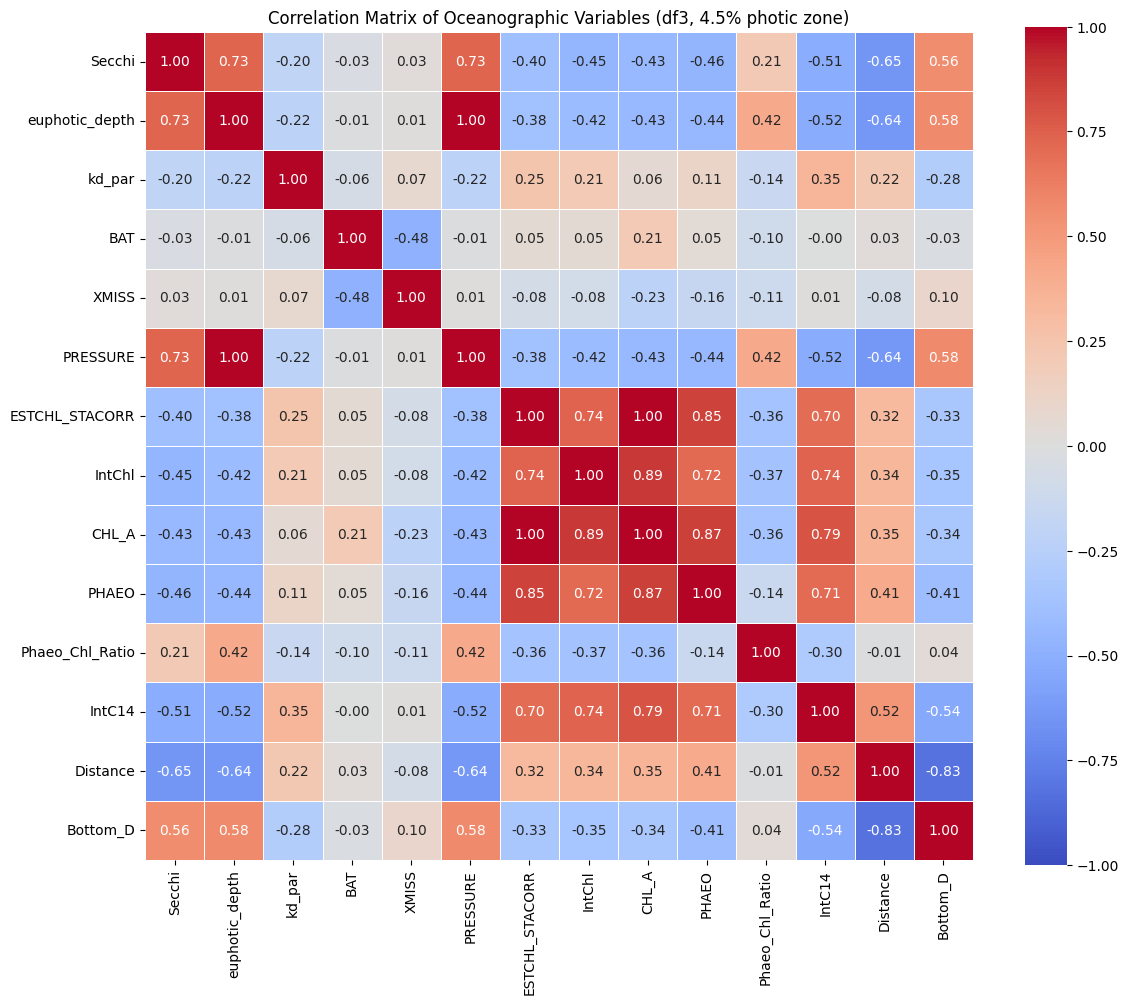

In [6]:
import seaborn as sns

def compute_cast_features(group):
    """Compute cast-level features using PHOTIC_ZONE column from df3."""
    group = group.sort_values('DEPTH')
    result = {}
    
    # Cast-level variables (one per cast — use first valid value)
    for col in ['Secchi', 'IntChl', 'IntC14', 'Distance', 'Bottom_D']:
        valid = group[col].dropna()
        result[col] = valid.iloc[0] if len(valid) > 0 else np.nan
    
    # Filter to photic zone rows
    photic = group[group['PHOTIC_ZONE'] == 1]
    
    # Euphotic depth = max depth within photic zone
    if len(photic) > 0:
        result['euphotic_depth'] = photic['DEPTH'].max()
    else:
        result['euphotic_depth'] = np.nan
    
    # Mean of observation-level variables within photic zone
    result['BAT'] = photic['BAT'].mean()
    result['XMISS'] = photic['XMISS'].mean()
    result['PRESSURE'] = photic['PRESSURE'].mean()
    result['ESTCHL_STACORR'] = photic['ESTCHL_STACORR'].mean()
    result['CHL_A'] = photic['CHL_A'].mean()
    result['PHAEO'] = photic['PHAEO'].mean()
    
    # Phaeo/Chl ratio (from means)
    if pd.notna(result['PHAEO']) and pd.notna(result['CHL_A']) and result['CHL_A'] > 0:
        result['Phaeo_Chl_Ratio'] = result['PHAEO'] / result['CHL_A']
    else:
        result['Phaeo_Chl_Ratio'] = np.nan
    
    # kd_par (diffuse attenuation coefficient from linear fit of ln(PAR) vs depth)
    par_valid = group.dropna(subset=['PAR'])
    par_valid = par_valid[par_valid['PAR'] > 0]
    if len(par_valid) >= 3:
        ln_par = np.log(par_valid['PAR'].values)
        depths = par_valid['DEPTH'].values
        slope, _ = np.polyfit(depths, ln_par, 1)
        result['kd_par'] = -slope
    else:
        result['kd_par'] = np.nan
    
    return pd.Series(result)

cast_features = df3.groupby('CAST_COUNT').apply(compute_cast_features, include_groups=False)

# Build correlation matrix
corr_vars = ['Secchi', 'euphotic_depth', 'kd_par', 
             'BAT', 'XMISS', 'PRESSURE', 'ESTCHL_STACORR', 
             'IntChl', 'CHL_A', 'PHAEO', 'Phaeo_Chl_Ratio',
             'IntC14', 'Distance', 'Bottom_D']

corr_matrix = cast_features[corr_vars].astype(float).corr()

plt.figure(figsize=(12, 10))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', center=0,
            square=True, linewidths=0.5, vmin=-1, vmax=1)
plt.title('Correlation Matrix of Oceanographic Variables (df3, 4.5% photic zone)')
plt.tight_layout()
plt.show()

Correlation between Secchi depth and photic depth at each light threshold:
 Threshold        r  n casts
----------------------------
        1%   0.5451     1911
        2%   0.6659     1945
        3%   0.6457     1953
        4%   0.6942     1966
        5%   0.7090     1974
        6%   0.6442     1976
        7%   0.7036     1979
        8%   0.6423     1981
        9%   0.6961     1982
       10%   0.6837     1985
       11%   0.6730     1986
       12%   0.6635     1987
       13%   0.6578     1987
       14%   0.6466     1988
       15%   0.6350     1988


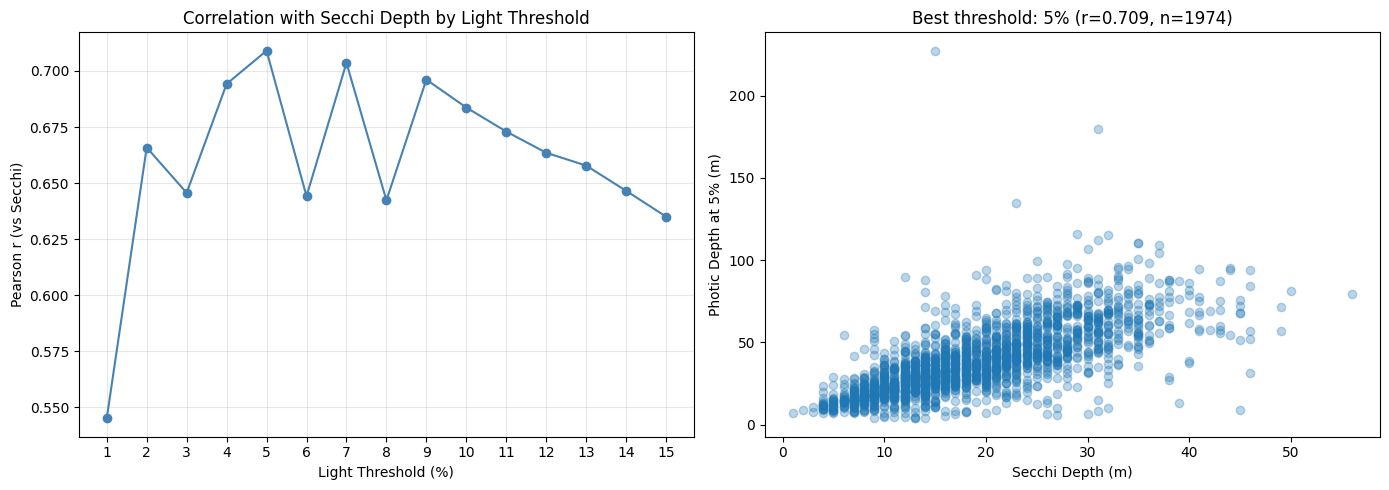

In [4]:
# Calculate photic depths at different light thresholds (1% to 15%) using 2m PAR as baseline

def calculate_photic_depth_at_threshold(group, threshold_pct):
    """Calculate depth where PAR drops to threshold_pct of 2m baseline."""
    group = group.sort_values('DEPTH').dropna(subset=['PAR'])
    
    depth_2m = group[group['DEPTH'] == 2.0]
    if len(depth_2m) == 0 or len(group) < 2:
        return np.nan
    
    surface_par = depth_2m['PAR'].iloc[0]
    if surface_par <= 0:
        return np.nan
    
    group = group[group['DEPTH'] >= 2.0].copy()
    group['PAR_pct'] = (group['PAR'] / surface_par) * 100
    
    above = group[group['PAR_pct'] >= threshold_pct]
    below = group[group['PAR_pct'] < threshold_pct]
    
    if len(above) == 0 or len(below) == 0:
        return np.nan
    
    d_a, d_b = above['DEPTH'].iloc[-1], below['DEPTH'].iloc[0]
    p_a, p_b = above['PAR_pct'].iloc[-1], below['PAR_pct'].iloc[0]
    
    return d_a + (d_b - d_a) * (p_a - threshold_pct) / (p_a - p_b)

# Calculate photic depth for each threshold and each cast
thresholds = range(1, 16)
secchi_per_cast = df3.groupby('CAST_COUNT')['Secchi'].first()

photic_depths = {}
for t in thresholds:
    photic_depths[f'photic_{t}pct'] = df3.groupby('CAST_COUNT').apply(
        lambda g: calculate_photic_depth_at_threshold(g, t), include_groups=False
    )

photic_df = pd.DataFrame(photic_depths)
photic_df['Secchi'] = secchi_per_cast

# Correlate each photic depth with Secchi
correlations = {}
counts = {}
for t in thresholds:
    col = f'photic_{t}pct'
    valid = photic_df[['Secchi', col]].dropna()
    correlations[t] = valid['Secchi'].corr(valid[col])
    counts[t] = len(valid)

# Display results
print("Correlation between Secchi depth and photic depth at each light threshold:")
print(f"{'Threshold':>10} {'r':>8} {'n casts':>8}")
print("-" * 28)
for t in thresholds:
    print(f"{t:>9}% {correlations[t]:>8.4f} {counts[t]:>8}")

# Plot correlations vs threshold
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(list(thresholds), [correlations[t] for t in thresholds], 'o-', color='steelblue')
axes[0].set_xlabel('Light Threshold (%)')
axes[0].set_ylabel('Pearson r (vs Secchi)')
axes[0].set_title('Correlation with Secchi Depth by Light Threshold')
axes[0].set_xticks(list(thresholds))
axes[0].grid(True, alpha=0.3)

# Scatter plot for the best threshold
best_t = max(correlations, key=correlations.get)
best_col = f'photic_{best_t}pct'
valid_best = photic_df[['Secchi', best_col]].dropna()

axes[1].scatter(valid_best['Secchi'], valid_best[best_col], alpha=0.3)
axes[1].set_xlabel('Secchi Depth (m)')
axes[1].set_ylabel(f'Photic Depth at {best_t}% (m)')
axes[1].set_title(f'Best threshold: {best_t}% (r={correlations[best_t]:.3f}, n={counts[best_t]})')

plt.tight_layout()
plt.show()

Correlation between Secchi depth and photic depth (4.0% - 5.5%):
 Threshold        r  n casts
----------------------------
      4.0%   0.6942     1966
      4.1%   0.6898     1968
      4.2%   0.6830     1970
      4.3%   0.6740     1970
      4.4%   0.6612     1970
      4.5%   0.7252     1970
      4.6%   0.7189     1971
      4.7%   0.7319     1971
      4.8%   0.7266     1973
      4.9%   0.7241     1973
      5.0%   0.7090     1974
      5.1%   0.7227     1974
      5.2%   0.7027     1974
      5.3%   0.6618     1974
      5.4%   0.6084     1974
      5.5%   0.6944     1974


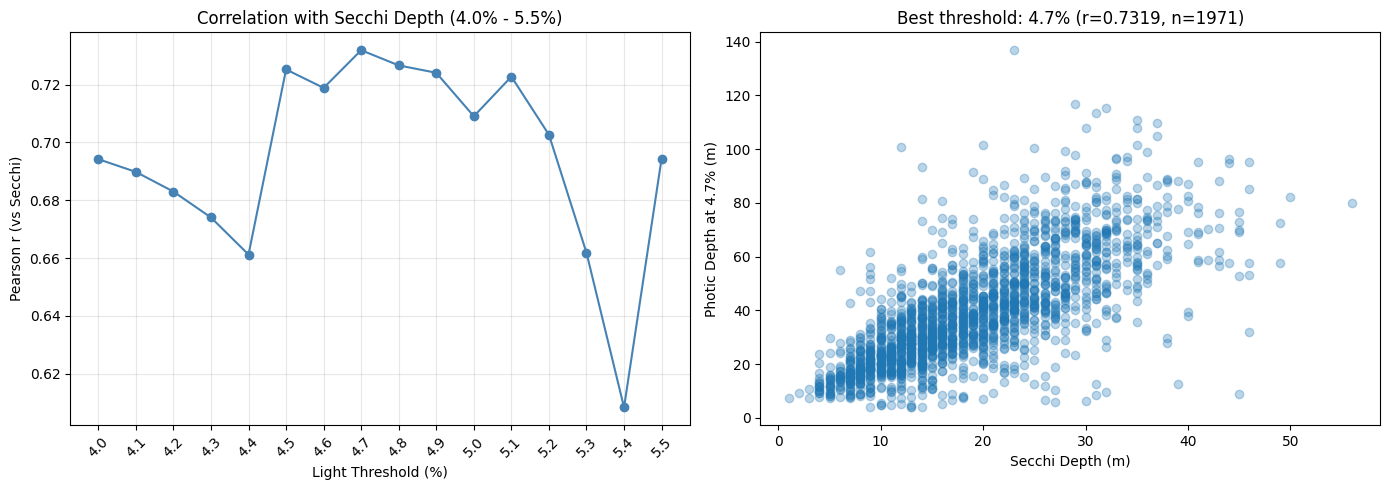

In [47]:
# Fine-grained photic depth thresholds: 4.0% to 5.5% in 0.1% increments

thresholds_fine = [round(x * 0.1, 1) for x in range(40, 56)]
secchi_per_cast = df3.groupby('CAST_COUNT')['Secchi'].first()

photic_depths_fine = {}
for t in thresholds_fine:
    photic_depths_fine[f'photic_{t}pct'] = df3.groupby('CAST_COUNT').apply(
        lambda g, thresh=t: calculate_photic_depth_at_threshold(g, thresh), include_groups=False
    )

photic_df_fine = pd.DataFrame(photic_depths_fine)
photic_df_fine['Secchi'] = secchi_per_cast

# Correlate each with Secchi
correlations_fine = {}
counts_fine = {}
for t in thresholds_fine:
    col = f'photic_{t}pct'
    valid = photic_df_fine[['Secchi', col]].dropna()
    correlations_fine[t] = valid['Secchi'].corr(valid[col])
    counts_fine[t] = len(valid)

# Display results
print("Correlation between Secchi depth and photic depth (4.0% - 5.5%):")
print(f"{'Threshold':>10} {'r':>8} {'n casts':>8}")
print("-" * 28)
for t in thresholds_fine:
    print(f"{t:>9.1f}% {correlations_fine[t]:>8.4f} {counts_fine[t]:>8}")

# Plot
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(thresholds_fine, [correlations_fine[t] for t in thresholds_fine], 'o-', color='steelblue')
axes[0].set_xlabel('Light Threshold (%)')
axes[0].set_ylabel('Pearson r (vs Secchi)')
axes[0].set_title('Correlation with Secchi Depth (4.0% - 5.5%)')
axes[0].set_xticks(thresholds_fine)
axes[0].tick_params(axis='x', rotation=45)
axes[0].grid(True, alpha=0.3)

# Scatter plot for the best threshold
best_t_fine = max(correlations_fine, key=correlations_fine.get)
best_col_fine = f'photic_{best_t_fine}pct'
valid_best_fine = photic_df_fine[['Secchi', best_col_fine]].dropna()

axes[1].scatter(valid_best_fine['Secchi'], valid_best_fine[best_col_fine], alpha=0.3)
axes[1].set_xlabel('Secchi Depth (m)')
axes[1].set_ylabel(f'Photic Depth at {best_t_fine}% (m)')
axes[1].set_title(f'Best threshold: {best_t_fine}% (r={correlations_fine[best_t_fine]:.4f}, n={counts_fine[best_t_fine]})')

plt.tight_layout()
plt.show()

Might just stick with the 4.5% light transmission calculation for photic depth rather than using 4.7%. Don't want to just arbitrarily fit a model with a photic depth predictor randomly at 4.7% light transmission because it improved the R value (correlation) on training data. It might then overfit and no generalize well.

It's important to make decisions based on a research public basis or on known oceanographic facts (which is what the 1% threshold does).

Need to validate this photic depth calculation approach - so test how well our model generalizes on a test set of set the photic zone threshold using cross-validation.

4.4 - 4.5% spikes correlation by 0.06, could be just due to some bias at a station.

Cross-validated correlation (10-fold) between Secchi and photic depth:
 Threshold   Mean r    Std r
----------------------------
      3.0%   0.6826   0.1131
      3.1%   0.6790   0.1231
      3.2%   0.6774   0.1326
      3.3%   0.6729   0.1426
      3.4%   0.6714   0.1471
      3.5%   0.7016   0.1085
      3.6%   0.6698   0.1330
      3.7%   0.6729   0.1267
      3.8%   0.6758   0.1196
      3.9%   0.7064   0.0683
      4.0%   0.7089   0.0693
      4.1%   0.7086   0.0718
      4.2%   0.7083   0.0783
      4.3%   0.7071   0.0845
      4.4%   0.7031   0.0919
      4.5%   0.7286   0.0440
      4.6%   0.7247   0.0547
      4.7%   0.7337   0.0351
      4.8%   0.7285   0.0401
      4.9%   0.7264   0.0433
      5.0%   0.7151   0.0602
      5.1%   0.7255   0.0461
      5.2%   0.7101   0.0662
      5.3%   0.6905   0.1058
      5.4%   0.6733   0.1367
      5.5%   0.7084   0.0737
      5.6%   0.7046   0.0809
      5.7%   0.7028   0.0862
      5.8%   0.6749   0.1183
      5.9%   0.6892   0.1014
 

/var/folders/xn/9gqx3sxx3s32k1ttvhjc4fch0000gn/T/ipykernel_44660/669753573.py:75: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[1].boxplot(box_data, labels=[f'{t}%' for t in top_thresholds])


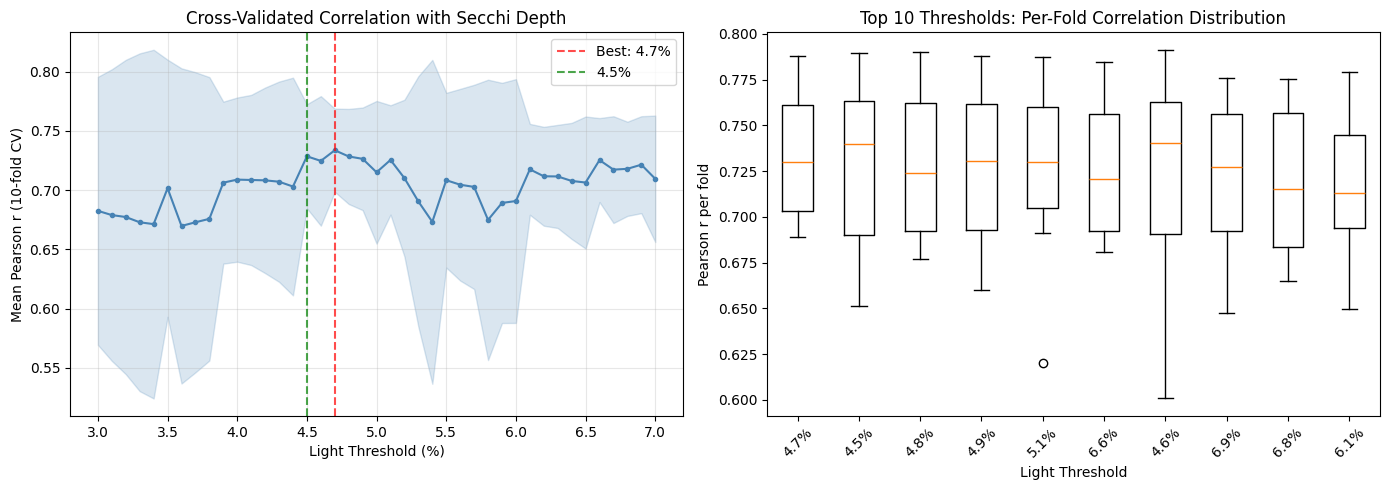

In [7]:
from sklearn.model_selection import KFold

# Cross-validated threshold selection: 3% to 7% in 0.1% steps
thresholds_cv = [round(x * 0.1, 1) for x in range(30, 71)]

# Pre-compute photic depths for all thresholds and all casts
secchi_per_cast = df3.groupby('CAST_COUNT')['Secchi'].first()

photic_all = {}
for t in thresholds_cv:
    photic_all[t] = df3.groupby('CAST_COUNT').apply(
        lambda g, thresh=t: calculate_photic_depth_at_threshold(g, thresh), include_groups=False
    )

# Build a DataFrame: rows = casts, columns = thresholds + Secchi
cv_df = pd.DataFrame(photic_all)
cv_df['Secchi'] = secchi_per_cast

# Drop casts with no Secchi
cv_df = cv_df.dropna(subset=['Secchi'])

# 10-fold cross-validation
kf = KFold(n_splits=10, shuffle=True, random_state=42)
cast_indices = np.arange(len(cv_df))

# Store per-fold correlations for each threshold
fold_correlations = {t: [] for t in thresholds_cv}

for train_idx, test_idx in kf.split(cast_indices):
    test_data = cv_df.iloc[test_idx]
    for t in thresholds_cv:
        valid = test_data[['Secchi', t]].dropna()
        if len(valid) >= 10:
            r = valid['Secchi'].corr(valid[t])
            fold_correlations[t].append(r)
        else:
            fold_correlations[t].append(np.nan)

# Compute mean and std of correlations across folds
mean_corr = {t: np.nanmean(fold_correlations[t]) for t in thresholds_cv}
std_corr = {t: np.nanstd(fold_correlations[t]) for t in thresholds_cv}

# Display results
print("Cross-validated correlation (10-fold) between Secchi and photic depth:")
print(f"{'Threshold':>10} {'Mean r':>8} {'Std r':>8}")
print("-" * 28)
for t in thresholds_cv:
    print(f"{t:>9.1f}% {mean_corr[t]:>8.4f} {std_corr[t]:>8.4f}")

best_t_cv = max(mean_corr, key=mean_corr.get)
print(f"\nBest threshold: {best_t_cv}% (mean r = {mean_corr[best_t_cv]:.4f} +/- {std_corr[best_t_cv]:.4f})")

# Plot
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

means = [mean_corr[t] for t in thresholds_cv]
stds = [std_corr[t] for t in thresholds_cv]

axes[0].plot(thresholds_cv, means, 'o-', color='steelblue', markersize=3)
axes[0].fill_between(thresholds_cv, 
                      [m - s for m, s in zip(means, stds)],
                      [m + s for m, s in zip(means, stds)],
                      alpha=0.2, color='steelblue')
axes[0].axvline(x=best_t_cv, color='red', linestyle='--', alpha=0.7, label=f'Best: {best_t_cv}%')
axes[0].axvline(x=4.5, color='green', linestyle='--', alpha=0.7, label='4.5%')
axes[0].set_xlabel('Light Threshold (%)')
axes[0].set_ylabel('Mean Pearson r (10-fold CV)')
axes[0].set_title('Cross-Validated Correlation with Secchi Depth')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Box plot of per-fold correlations for top candidates
top_thresholds = sorted(mean_corr, key=mean_corr.get, reverse=True)[:10]
box_data = [fold_correlations[t] for t in top_thresholds]
axes[1].boxplot(box_data, labels=[f'{t}%' for t in top_thresholds])
axes[1].set_xlabel('Light Threshold')
axes[1].set_ylabel('Pearson r per fold')
axes[1].set_title('Top 10 Thresholds: Per-Fold Correlation Distribution')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

In [5]:
# Cross-validated threshold selection (fine-grained): 4.5% to 4.8% in 0.01% steps
thresholds_cv_fine = [round(x * 0.01, 2) for x in range(450, 481)]

# Pre-compute photic depths for all thresholds and all casts
secchi_per_cast = df3.groupby('CAST_COUNT')['Secchi'].first()

photic_all_fine = {}
for t in thresholds_cv_fine:
    photic_all_fine[t] = df3.groupby('CAST_COUNT').apply(
        lambda g, thresh=t: calculate_photic_depth_at_threshold(g, thresh), include_groups=False
    )

# Build a DataFrame: rows = casts, columns = thresholds + Secchi
cv_df_fine = pd.DataFrame(photic_all_fine)
cv_df_fine['Secchi'] = secchi_per_cast

# Drop casts with no Secchi
cv_df_fine = cv_df_fine.dropna(subset=['Secchi'])

# 10-fold cross-validation
kf = KFold(n_splits=10, shuffle=True, random_state=42)
cast_indices = np.arange(len(cv_df_fine))

# Store per-fold correlations for each threshold
fold_correlations_fine = {t: [] for t in thresholds_cv_fine}

for train_idx, test_idx in kf.split(cast_indices):
    test_data = cv_df_fine.iloc[test_idx]
    for t in thresholds_cv_fine:
        valid = test_data[['Secchi', t]].dropna()
        if len(valid) >= 10:
            r = valid['Secchi'].corr(valid[t])
            fold_correlations_fine[t].append(r)
        else:
            fold_correlations_fine[t].append(np.nan)

# Compute mean and std of correlations across folds
mean_corr_fine = {t: np.nanmean(fold_correlations_fine[t]) for t in thresholds_cv_fine}
std_corr_fine = {t: np.nanstd(fold_correlations_fine[t]) for t in thresholds_cv_fine}

# Display results
print("Cross-validated correlation (10-fold) between Secchi and photic depth (4.50% - 4.80%):")
print(f"{'Threshold':>10} {'Mean r':>8} {'Std r':>8}")
print("-" * 28)
for t in thresholds_cv_fine:
    print(f"{t:>9.2f}% {mean_corr_fine[t]:>8.4f} {std_corr_fine[t]:>8.4f}")

best_t_cv_fine = max(mean_corr_fine, key=mean_corr_fine.get)
print(f"\nBest threshold: {best_t_cv_fine}% (mean r = {mean_corr_fine[best_t_cv_fine]:.4f} +/- {std_corr_fine[best_t_cv_fine]:.4f})")

# Plot
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

means_fine = [mean_corr_fine[t] for t in thresholds_cv_fine]
stds_fine = [std_corr_fine[t] for t in thresholds_cv_fine]

axes[0].plot(thresholds_cv_fine, means_fine, 'o-', color='steelblue', markersize=3)
axes[0].fill_between(thresholds_cv_fine, 
                      [m - s for m, s in zip(means_fine, stds_fine)],
                      [m + s for m, s in zip(means_fine, stds_fine)],
                      alpha=0.2, color='steelblue')
axes[0].axvline(x=best_t_cv_fine, color='red', linestyle='--', alpha=0.7, label=f'Best: {best_t_cv_fine}%')
axes[0].axvline(x=4.5, color='green', linestyle='--', alpha=0.7, label='4.5%')
axes[0].set_xlabel('Light Threshold (%)')
axes[0].set_ylabel('Mean Pearson r (10-fold CV)')
axes[0].set_title('Cross-Validated Correlation with Secchi Depth (4.50% - 4.80%)')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Box plot of per-fold correlations for top candidates
top_thresholds_fine = sorted(mean_corr_fine, key=mean_corr_fine.get, reverse=True)[:10]
box_data_fine = [fold_correlations_fine[t] for t in top_thresholds_fine]
axes[1].boxplot(box_data_fine, labels=[f'{t}%' for t in top_thresholds_fine])
axes[1].set_xlabel('Light Threshold')
axes[1].set_ylabel('Pearson r per fold')
axes[1].set_title('Top 10 Thresholds: Per-Fold Correlation Distribution')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

NameError: name 'KFold' is not defined

In [6]:
# How many casts have both Secchi and photic depth (at 4.5% threshold)?
secchi_per_cast = df3.groupby('CAST_COUNT')['Secchi'].first()
photic_45 = df3.groupby('CAST_COUNT').apply(
    lambda g: calculate_photic_depth_at_threshold(g, 4.5), include_groups=False
)

combined = pd.DataFrame({'Secchi': secchi_per_cast, 'photic_depth_4.5pct': photic_45})
print(f"Total casts: {len(combined)}")
print(f"Casts with Secchi: {combined['Secchi'].notna().sum()}")
print(f"Casts with photic depth (4.5%): {combined['photic_depth_4.5pct'].notna().sum()}")
print(f"Casts with BOTH: {combined.dropna().shape[0]}")

Total casts: 2774
Casts with Secchi: 2774
Casts with photic depth (4.5%): 1970
Casts with BOTH: 1970


Using 10 fold Cross Validation, the Secchi-photic depth correlation was computed to see if a photic threshold holds up across different subsets of the data. Computes the correlation for 3-7% in 1 fold out of 10, repeated 10 times, then averages the correlations and thus creates standard deviations as well.

With this we can ask if this photic threshold reliably correlates with Secchi no matter which casts are looked at, helps with robustness.

#### Can we engineer more features? 
- Kd
- Season
- Use LAT and LON